# 🏔️ Interactive DEM Explorer & Hydrologic Analysis
> **Google Colab Notebook** — Interactive terrain mapping, stream extraction & watershed delineation

---

## Workflow Overview
| Step | Description |
|------|-------------|
| **0. Install** | One-shot dependency install |
| **1. Config** | Central settings (location, DEM source, threshold) |
| **1.5. Points of Interest** | Add / import POIs; optionally auto-zoom map to data extent |
| **2. Basemap** | Browse OSM / Satellite / Topo layers interactively with POIs overlaid |
| **3. DEM Download** | Fetch SRTM 30 m from AWS public bucket *(no sign-up required)* |
| **4. Statistics** | Min / max / mean elevation, slope, hypsometric curve |
| **5. Hydrology** | Pit-fill → Flow direction → Flow accumulation → Stream network |
| **6. Threshold Tuning** | Interactive slider — stream density preview |
| **7. Watershed Delineation** | Click map **or** type coordinates → snap → catchment boundary + export |
| **8. Export** | GeoTIFF, GeoJSON, Shapefile, PNG figures |

**SRTM source:** AWS Terrain Tiles public bucket (`elevation-tiles-prod`) — no API key needed.


## ⚙️ Step 0 — Install Dependencies
Run once per Colab session.

In [1]:
import subprocess, sys

# Install packages (quiet, no %%capture so widget manager initialises cleanly)
pkgs = [
    "ipyleaflet", "pysheds", "rasterio", "geopandas",
    "scikit-image", "shapely", "requests", "fiona"
]
print("Installing packages …")
result = subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q", "--disable-pip-version-check"] + pkgs,
    capture_output=True, text=True
)
if result.returncode != 0:
    print("⚠️ pip stderr:\n", result.stderr[-2000:])
else:
    print("✅ pip install OK")

# Now import — widget manager initialises normally (no %%capture in scope)
import pysheds, rasterio, ipyleaflet
print(f"   pysheds    {pysheds.__version__}")
print(f"   rasterio   {rasterio.__version__}")
print(f"   ipyleaflet {ipyleaflet.__version__}")

Installing packages …
✅ pip install OK
   pysheds    0.5
   rasterio   1.5.0
   ipyleaflet 0.20.0


## 📦 Step 1 — Imports & Configuration

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.colors import LightSource
from matplotlib.cm import ScalarMappable
import rasterio
from rasterio.transform import from_bounds, rowcol
from rasterio.crs import CRS
from rasterio.merge import merge
from rasterio.mask import mask as rio_mask
import geopandas as gpd
from shapely.geometry import shape, LineString, Point, mapping, MultiLineString
import requests, gzip, os, json, io, warnings
warnings.filterwarnings('ignore')

from ipyleaflet import (
    Map, TileLayer, LayersControl, ScaleControl,
    FullScreenControl, Rectangle, Marker, MarkerCluster,
    GeoJSON as LeafletGeoJSON, CircleMarker, Popup
)
import ipywidgets as widgets
from ipywidgets import (Button, Output, VBox, HBox, HTML, Layout,
                        IntSlider, Text, Textarea, Tab, FileUpload,
                        Dropdown, Label, FloatText, ToggleButton)
from IPython.display import display, clear_output
import traitlets

print("✅ Imports OK")


✅ Imports OK


In [4]:
# ╔══════════════════════════════════════════════════════════╗
# ║               ⚙️  USER CONFIGURATION                     ║
# ╚══════════════════════════════════════════════════════════╝

# ── Map defaults ──────────────────────────────────────────
DEFAULT_CENTER = [16.920, 121.060]   # Banaue Rice Terraces, PH
DEFAULT_ZOOM   = 11

# ── DEM source ────────────────────────────────────────────
# 'aws_srtm'       → SRTM 1-arcsec (~30 m), no sign-up, global 60°N–56°S
# 'opentopography' → Free key at https://opentopography.org/developers
DEM_SOURCE   = 'aws_srtm'
OT_API_KEY   = 'YOUR_KEY_HERE'
OT_DEM_TYPE  = 'SRTMGL1'            # SRTMGL1 | COP30 | NASADEM | AW3D30

# ── Hydrologic threshold ──────────────────────────────────
STREAM_THRESHOLD = 50

# ── Output paths ──────────────────────────────────────────
DEM_PATH        = '/content/dem.tif'
STREAMS_JSON    = '/content/streams.geojson'
STREAMS_SHP     = '/content/streams.shp'
WATERSHED_JSON  = '/content/watershed.geojson'
WATERSHED_SHP   = '/content/watershed.shp'
FIG_TERRAIN     = '/content/terrain_analysis.png'
FIG_HYDRO       = '/content/hydrology_analysis.png'
FIG_WATERSHED   = '/content/watershed.png'

print("✅ Configuration loaded")
print(f"   DEM source       : {DEM_SOURCE}")
print(f"   Default location : {DEFAULT_CENTER}")
print(f"   Stream threshold : {STREAM_THRESHOLD:,} cells")


✅ Configuration loaded
   DEM source       : aws_srtm
   Default location : [16.92, 121.06]
   Stream threshold : 50 cells


## 📍 Step 1.5 — Points of Interest (Optional)

Add named points manually **or** import a vector file (GeoJSON / Shapefile).  
POIs will appear on the basemap in Step 2 and can be used to:
- Guide your map navigation
- Auto-fit the basemap to the data extent
- Be exported alongside your analysis outputs

### Usage
- **Tab A – Manual entry**: type coordinates one by one  
- **Tab B – Paste GeoJSON**: paste raw GeoJSON FeatureCollection  
- **Tab C – Upload file**: upload `.geojson` or `.zip` (zipped shapefile)  
Then click **➕ Add to Map** or **🗺️ Fit Map to POIs** after adding points.


In [7]:
# ══════════════════════════════════════════════════════════════════════════════
#  POINTS OF INTEREST MANAGER  (flat layout — Colab-safe)
# ══════════════════════════════════════════════════════════════════════════════

poi_store       = []   # [{name, lat, lon, color}]
_poi_markers_map = []  # filled in Step 2

COLORS = ['blue','red','green','orange','purple','darkred',
          'cadetblue','darkblue','darkgreen','gray']

def _add_poi(name, lat, lon, color='blue'):
    poi_store.append(dict(name=name, lat=float(lat), lon=float(lon), color=color))

out_poi_table = Output()

def _refresh_table():
    out_poi_table.clear_output()
    with out_poi_table:
        if not poi_store:
            display(HTML("<i style='color:#888'>No POIs added yet.</i>"))
            return
        rows = "".join(
            f"<tr><td style='padding:3px 8px'>{i+1}</td>"
            f"<td style='padding:3px 8px'>{p['name']}</td>"
            f"<td style='padding:3px 8px'>{p['lat']:.5f}</td>"
            f"<td style='padding:3px 8px'>{p['lon']:.5f}</td>"
            f"<td style='padding:3px 8px'>"
            f"<span style='background:{p['color']};color:#fff;"
            f"padding:1px 10px;border-radius:4px'>{p['color']}</span></td></tr>"
            for i, p in enumerate(poi_store)
        )
        display(HTML(
            "<table style='border-collapse:collapse;font-size:13px'>"
            "<tr style='background:#e8eaf6;font-weight:bold'>"
            "<th style='padding:4px 8px'>#</th>"
            "<th style='padding:4px 8px'>Name</th>"
            "<th style='padding:4px 8px'>Latitude</th>"
            "<th style='padding:4px 8px'>Longitude</th>"
            "<th style='padding:4px 8px'>Color</th></tr>"
            + rows + "</table>"
            f"<p style='color:#2e7d32;margin:6px 0'><b>{len(poi_store)} POI(s) loaded.</b></p>"
        ))

# ── Section A: Manual entry ────────────────────────────────────────────────────
w_name  = widgets.Text(description='Name:',      placeholder='e.g. Dam Site',
                       layout=Layout(width='280px'))
w_lat   = widgets.FloatText(description='Lat:',  value=DEFAULT_CENTER[0],
                            step=0.0001, layout=Layout(width='200px'))
w_lon   = widgets.FloatText(description='Lon:',  value=DEFAULT_CENTER[1],
                            step=0.0001, layout=Layout(width='200px'))
w_color = widgets.Dropdown(description='Color:', options=COLORS, value='blue',
                           layout=Layout(width='180px'))
btn_add = Button(description='➕ Add Point', button_style='primary',
                 layout=Layout(width='130px'))
btn_ex  = Button(description='Load Examples', button_style='',
                 layout=Layout(width='130px'))

def on_add(b):
    name = w_name.value.strip() or f"POI-{len(poi_store)+1}"
    _add_poi(name, w_lat.value, w_lon.value, w_color.value)
    w_name.value = ''
    _refresh_table()

def on_examples(b):
    for nm, lt, ln, cl in [
        ('Banaue Viewpoint', 16.9185, 121.0600, 'red'),
        ('Batad Village',    16.9071, 121.1015, 'blue'),
        ('Cambulo Village',  16.8897, 121.0887, 'green'),
    ]:
        _add_poi(nm, lt, ln, cl)
    _refresh_table()

btn_add.on_click(on_add)
btn_ex.on_click(on_examples)

# ── Section B: Paste GeoJSON ───────────────────────────────────────────────────
w_gjson    = widgets.Textarea(placeholder='Paste GeoJSON FeatureCollection here …',
                              layout=Layout(width='99%', height='120px'))
btn_parse  = Button(description='📥 Import GeoJSON', button_style='info',
                    layout=Layout(width='160px'))
out_gj_msg = Output()

def on_parse_gj(b):
    out_gj_msg.clear_output()
    try:
        fc    = json.loads(w_gjson.value.strip())
        feats = fc.get('features', [fc]) if fc.get('type') == 'FeatureCollection' else [fc]
        n = 0
        for feat in feats:
            geom  = feat.get('geometry', {})
            props = feat.get('properties', {}) or {}
            name  = (props.get('name') or props.get('Name') or
                     props.get('label') or f"POI-{len(poi_store)+1}")
            if geom.get('type') == 'Point':
                lo, la = geom['coordinates'][:2]
                _add_poi(name, la, lo); n += 1
            else:
                c = shape(geom).centroid
                _add_poi(f"{name} (centroid)", c.y, c.x, 'purple'); n += 1
        _refresh_table()
        with out_gj_msg:
            print(f"✅ Imported {n} feature(s)")
    except Exception as ex:
        with out_gj_msg:
            print(f"❌ Error: {ex}")

btn_parse.on_click(on_parse_gj)

# ── Section C: Upload file ─────────────────────────────────────────────────────
w_upload     = widgets.FileUpload(accept='.geojson,.json,.zip',
                                  multiple=False, layout=Layout(width='260px'))
btn_import   = Button(description='📂 Import File', button_style='warning',
                      layout=Layout(width='140px'))
out_file_msg = Output()

def on_import_file(b):
    out_file_msg.clear_output()
    if not w_upload.value:
        with out_file_msg: print("⚠️ Select a file first.")
        return
    try:
        fname = list(w_upload.value.keys())[0]
        raw   = w_upload.value[fname]['content']
        ext   = os.path.splitext(fname)[1].lower()
        n     = 0
        if ext in ('.geojson', '.json'):
            fc    = json.loads(raw.decode('utf-8'))
            feats = fc.get('features', [fc]) if fc.get('type')=='FeatureCollection' else [fc]
            for feat in feats:
                geom  = feat.get('geometry', {})
                props = feat.get('properties', {}) or {}
                name  = (props.get('name') or props.get('Name') or
                         f"POI-{len(poi_store)+1}")
                if geom.get('type') == 'Point':
                    lo, la = geom['coordinates'][:2]
                    _add_poi(name, la, lo); n += 1
                else:
                    c = shape(geom).centroid
                    _add_poi(f"{name} (centroid)", c.y, c.x, 'purple'); n += 1
        elif ext == '.zip':
            import zipfile, tempfile
            with tempfile.TemporaryDirectory() as tmp:
                zp = os.path.join(tmp, fname)
                with open(zp, 'wb') as f: f.write(raw)
                with zipfile.ZipFile(zp) as zf: zf.extractall(tmp)
                shps = [os.path.join(tmp, x) for x in os.listdir(tmp)
                        if x.endswith('.shp')]
                if not shps:
                    with out_file_msg: print("❌ No .shp in ZIP."); return
                gdf_in = gpd.read_file(shps[0]).to_crs(epsg=4326)
                for _, row in gdf_in.iterrows():
                    nm = (row.get('name') or row.get('Name') or
                          row.get('label') or f"POI-{len(poi_store)+1}")
                    c  = row.geometry.centroid
                    _add_poi(str(nm), c.y, c.x); n += 1
        else:
            with out_file_msg: print("⚠️ Use .geojson, .json, or .zip"); return
        _refresh_table()
        with out_file_msg: print(f"✅ Imported {n} feature(s) from {fname}")
    except Exception as ex:
        with out_file_msg: print(f"❌ Error: {ex}")

btn_import.on_click(on_import_file)

# ── Bottom controls ────────────────────────────────────────────────────────────
btn_clear  = Button(description='🗑️ Clear All', button_style='danger',
                    layout=Layout(width='110px'))
btn_export = Button(description='💾 Export POIs', layout=Layout(width='130px'))

def on_clear(b):
    poi_store.clear(); _refresh_table()

def on_export(b):
    if not poi_store: print("No POIs to export."); return
    gdf_p = gpd.GeoDataFrame(poi_store,
                              geometry=[Point(p['lon'], p['lat']) for p in poi_store],
                              crs='EPSG:4326')
    gdf_p.to_file('/content/points_of_interest.geojson', driver='GeoJSON')
    gdf_p.to_file('/content/points_of_interest.shp')
    print("✅ /content/points_of_interest.geojson  &  .shp")

btn_clear.on_click(on_clear)
btn_export.on_click(on_export)

# ── Render ─────────────────────────────────────────────────────────────────────
div  = lambda txt, **kw: HTML(f"<div style='margin:10px 0 4px 0'><b>{txt}</b></div>", **kw)
rule = HTML("<hr style='border:none;border-top:1px solid #ddd;margin:12px 0'>")

display(VBox([
    HTML("<h3 style='margin:4px 0'>📍 Points of Interest Manager</h3>"),

    div("A — Manual Entry"),
    HBox([w_name, w_lat, w_lon, w_color]),
    HBox([btn_add, btn_ex]),

    rule,
    div("B — Paste GeoJSON"),
    w_gjson,
    HBox([btn_parse, out_gj_msg]),

    rule,
    div("C — Upload GeoJSON or Zipped Shapefile"),
    HBox([w_upload, btn_import]),
    out_file_msg,

    rule,
    HBox([btn_clear, btn_export]),
    HTML("<b>Current POIs:</b>"),
    out_poi_table,
]))

_refresh_table()

## 🗺️ Step 2 — Interactive Basemap
1. Your POIs (from Step 1.5) appear as coloured markers — click any for its name.  
2. **Switch layers** with the layer control (top-right).  
3. Pan & zoom to your study area, then click **📍 Capture Current View**.  
4. A red bounding box confirms the captured extent with coordinates shown below.

> 💡 Click **🎯 Fit to POIs** to auto-zoom the map to all loaded points.


In [10]:
# ═══════════════════════════════════════════════════════════════════════════
#  INTERACTIVE BASEMAP WITH POI OVERLAY
# ═══════════════════════════════════════════════════════════════════════════

m = Map(
    center=DEFAULT_CENTER,
    zoom=DEFAULT_ZOOM,
    scroll_wheel_zoom=True,
    layout=Layout(height='540px', width='100%')
)

# ── Tile layers ───────────────────────────────────────────────────────────────
_tiles = [
    TileLayer(url='https://{s}.tile.openstreetmap.org/{z}/{x}/{y}.png',
              attribution='© OpenStreetMap', name='OpenStreetMap'),
    TileLayer(url='https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',
              attribution='Esri', name='Satellite (Esri)'),
    TileLayer(url='https://{s}.tile.opentopomap.org/{z}/{x}/{y}.png',
              attribution='© OpenTopoMap', name='OpenTopoMap'),
    TileLayer(url='https://{s}.basemaps.cartocdn.com/light_all/{z}/{x}/{y}.png',
              attribution='© CartoDB', name='CartoDB Light'),
]
for t in _tiles:
    m.add_layer(t)
m.add_control(LayersControl(position='topright'))
m.add_control(ScaleControl(position='bottomleft'))
m.add_control(FullScreenControl())

# ── POI colour map → Leaflet icon colours ─────────────────────────────────────
_LEAFLET_COLORS = {c: c for c in COLORS}
_poi_markers_map = []

def _add_poi_to_map(poi):
    """Add a single POI dict as a CircleMarker on the live map."""
    cm = CircleMarker(
        location=(poi['lat'], poi['lon']),
        radius=8, color='white', weight=2,
        fill_color=poi['color'], fill_opacity=0.92
    )
    cm.popup = Popup(child=HTML(
        f"<b>{poi['name']}</b><br>"
        f"<small>{poi['lat']:.5f}°, {poi['lon']:.5f}°</small>"
    ), close_button=False, auto_close=True)
    m.add_layer(cm)
    _poi_markers_map.append(cm)

def refresh_poi_markers():
    """Remove old POI markers and re-draw from poi_store."""
    for mk in _poi_markers_map:
        try: m.remove_layer(mk)
        except: pass
    _poi_markers_map.clear()
    for p in poi_store:
        _add_poi_to_map(p)

# Draw whatever is already in poi_store (from Step 1.5)
refresh_poi_markers()

# ── Capture state ─────────────────────────────────────────────────────────────
captured_bounds = {}
_bbox_layer = [None]
out_info    = Output()

def _set_info(html, color='#2e7d32'):
    out_info.clear_output()
    with out_info:
        display(HTML(
            f"<div style='padding:10px 14px;border-left:4px solid {color};"
            f"background:#f9f9f9;font-family:monospace;font-size:13px'>{html}</div>"
        ))

def on_capture(b):
    bds = m.bounds
    if not bds or len(bds) < 2:
        _set_info('⚠️ Map not ready — wait a moment and try again.', '#e65100')
        return
    s, w = bds[0][0], bds[0][1]
    n, e = bds[1][0], bds[1][1]
    captured_bounds.update(south=s, west=w, north=n, east=e)

    if _bbox_layer[0]:
        try: m.remove_layer(_bbox_layer[0])
        except: pass
    rect = Rectangle(bounds=[(s, w), (n, e)], color='red',
                     fill=False, weight=2, dash_array='6')
    m.add_layer(rect)
    _bbox_layer[0] = rect

    area_km2 = ((n-s) * (e-w) * 111.32**2 * np.cos(np.radians((n+s)/2)))
    warn = ''
    if (n-s)*(e-w) > 1.5:
        warn = "<br>⚠️ <b>Large area</b> — download may be slow."
    elif (n-s)*(e-w) < 0.001:
        warn = "<br>⚠️ <b>Very small area</b> — zoom out for useful coverage."

    _set_info(
        f"✅ <b>Bounds captured!</b>{warn}<br><br>"
        f"&nbsp; North : <b>{n:.5f}°</b><br>"
        f"&nbsp; South : <b>{s:.5f}°</b><br>"
        f"&nbsp; East  : <b>{e:.5f}°</b><br>"
        f"&nbsp; West  : <b>{w:.5f}°</b><br>"
        f"&nbsp; Area  : <b>~{area_km2:,.1f} km²</b>"
    )

def on_fit_pois(b):
    if not poi_store:
        _set_info('⚠️ No POIs loaded — add some in Step 1.5.', '#e65100')
        return
    lats = [p['lat'] for p in poi_store]
    lons = [p['lon'] for p in poi_store]
    pad = 0.05
    m.fit_bounds([
        [min(lats)-pad, min(lons)-pad],
        [max(lats)+pad, max(lons)+pad]
    ])
    refresh_poi_markers()
    _set_info(f"🎯 Map fitted to {len(poi_store)} POI(s).", '#1565c0')

def on_refresh_pois(b):
    refresh_poi_markers()
    _set_info(f"🔄 {len(poi_store)} POI marker(s) refreshed on map.", '#1565c0')

btn_capture     = Button(description='📍 Capture Current View',
                          button_style='success', layout=Layout(width='210px', height='38px'))
btn_fit_pois    = Button(description='🎯 Fit to POIs',
                          button_style='info',    layout=Layout(width='140px', height='38px'))
btn_refresh_poi = Button(description='🔄 Refresh POIs',
                          button_style='',        layout=Layout(width='140px', height='38px'))

btn_capture.on_click(on_capture)
btn_fit_pois.on_click(on_fit_pois)
btn_refresh_poi.on_click(on_refresh_pois)

display(VBox([
    HTML("<h3 style='margin:4px 0'>🗺️ Basemap Explorer</h3>"
         "<p style='color:#555;margin:2px 0'>Pan / zoom to your study area, then capture.</p>"),
    m,
    HBox([btn_capture, btn_fit_pois, btn_refresh_poi],
         layout=Layout(margin='8px 0 4px 0', gap='8px')),
    out_info
]))


## ⬇️ Step 3 — Download DEM

| Backend | Key | Resolution | Notes |
|---------|-----|-----------|-------|
| `aws_srtm` | None | ~30 m (1″) | NASA SRTM via AWS public bucket |
| `opentopography` | Free | COP30 / NASADEM / AW3D30 | More choices |


In [11]:
def _hgt_to_array(raw_bytes):
    n   = 3601
    arr = np.frombuffer(raw_bytes, dtype=np.dtype('>i2')).reshape(n, n).astype(np.float32)
    arr[arr == -32768] = np.nan
    return arr

def download_aws_srtm(bounds, output_path):
    s, w = bounds['south'], bounds['west']
    n, e = bounds['north'], bounds['east']
    lat_tiles = range(int(np.floor(s)), int(np.ceil(n)))
    lon_tiles = range(int(np.floor(w)), int(np.ceil(e)))
    print(f"📥 Fetching {len(lat_tiles)*len(lon_tiles)} SRTM tile(s) from AWS …")
    tmp_paths = []

    for lat in lat_tiles:
        for lon in lon_tiles:
            ns  = 'N' if lat >= 0 else 'S'
            ew  = 'E' if lon >= 0 else 'W'
            lat_s = f"{ns}{abs(lat):02d}"
            lon_s = f"{ew}{abs(lon):03d}"
            tile  = f"{lat_s}{lon_s}"
            url   = f"https://s3.amazonaws.com/elevation-tiles-prod/skadi/{lat_s}/{tile}.hgt.gz"
            print(f"   → {tile}", end='  ')
            resp  = requests.get(url, timeout=60)
            if resp.status_code == 404:
                print("(no data)"); continue
            resp.raise_for_status()
            arr = _hgt_to_array(gzip.decompress(resp.content))
            tfm = from_bounds(lon, lat, lon+1, lat+1, arr.shape[1], arr.shape[0])
            tmp = f'/tmp/_srtm_{tile}.tif'
            with rasterio.open(tmp, 'w', driver='GTiff',
                               height=arr.shape[0], width=arr.shape[1],
                               count=1, dtype='float32',
                               crs=CRS.from_epsg(4326), transform=tfm,
                               nodata=np.nan) as dst:
                dst.write(arr, 1)
            tmp_paths.append(tmp)
            print(f"✓ ({arr.shape[0]}×{arr.shape[1]})")

    if not tmp_paths:
        raise RuntimeError("No tiles downloaded. Check bbox and SRTM coverage (60°N–56°S).")

    if len(tmp_paths) == 1:
        src     = rasterio.open(tmp_paths[0])
        merged  = src.read(1); tfm_mrg = src.transform; src.close()
    else:
        srcs            = [rasterio.open(p) for p in tmp_paths]
        merged_arr, tfm_mrg = merge(srcs)
        merged          = merged_arr[0]
        for s in srcs: s.close()

    for p in tmp_paths: os.remove(p)

    r0, c0 = rowcol(tfm_mrg, w, n)
    r1, c1 = rowcol(tfm_mrg, e, s)
    r0, c0 = max(0, r0), max(0, c0)
    r1 = min(merged.shape[0], r1+1)
    c1 = min(merged.shape[1], c1+1)
    clipped     = merged[r0:r1, c0:c1]
    tfm_clipped = from_bounds(w, s, e, n, clipped.shape[1], clipped.shape[0])

    with rasterio.open(output_path, 'w', driver='GTiff',
                       height=clipped.shape[0], width=clipped.shape[1],
                       count=1, dtype='float32',
                       crs=CRS.from_epsg(4326), transform=tfm_clipped,
                       nodata=np.nan) as dst:
        dst.write(clipped, 1)

    kb = os.path.getsize(output_path) / 1024
    print(f"\n✅ DEM saved → {output_path}  ({clipped.shape[0]}×{clipped.shape[1]} cells, {kb:.1f} KB)")
    return output_path

def download_opentopography(bounds, api_key, dem_type, output_path):
    if api_key == 'YOUR_KEY_HERE':
        raise ValueError("Set OT_API_KEY in the config cell.")
    params = dict(demtype=dem_type,
                  south=bounds['south'], north=bounds['north'],
                  west=bounds['west'],  east=bounds['east'],
                  outputFormat='GTiff', API_Key=api_key)
    print(f"📥 Requesting {dem_type} from OpenTopography …")
    r = requests.get("https://portal.opentopography.org/API/globaldem",
                     params=params, stream=True, timeout=180)
    r.raise_for_status()
    with open(output_path, 'wb') as f:
        for chunk in r.iter_content(8192): f.write(chunk)
    print(f"✅ Downloaded {os.path.getsize(output_path)/1024:.1f} KB → {output_path}")
    return output_path

print("✅ DEM download functions defined")


✅ DEM download functions defined


In [12]:
assert captured_bounds, (
    "⚠️  No bounds captured yet!\n"
    "   Go to Step 2 → pan/zoom → click '📍 Capture Current View'."
)

print("Bounding box:")
print(f"  N={captured_bounds['north']:.5f}°  S={captured_bounds['south']:.5f}°")
print(f"  E={captured_bounds['east']:.5f}°   W={captured_bounds['west']:.5f}°\n")

if DEM_SOURCE == 'aws_srtm':
    download_aws_srtm(captured_bounds, DEM_PATH)
elif DEM_SOURCE == 'opentopography':
    download_opentopography(captured_bounds, OT_API_KEY, OT_DEM_TYPE, DEM_PATH)
else:
    raise ValueError(f"Unknown DEM_SOURCE: '{DEM_SOURCE}'")


Bounding box:
  N=16.44917°  S=16.42695°
  E=120.57680°   W=120.52560°

📥 Fetching 1 SRTM tile(s) from AWS …
   → N16E120  ✓ (3601×3601)

✅ DEM saved → /content/dem.tif  (81×186 cells, 59.3 KB)


## 📊 Step 4 — Elevation Statistics & Terrain Maps

In [13]:
with rasterio.open(DEM_PATH) as src:
    dem_raw   = src.read(1).astype(np.float32)
    _nodata   = src.nodata
    transform = src.transform
    crs       = src.crs
    bbox      = src.bounds

dem    = np.where(dem_raw == _nodata, np.nan, dem_raw) if _nodata is not None else dem_raw.copy()
extent = [bbox.left, bbox.right, bbox.bottom, bbox.top]
valid  = dem[~np.isnan(dem)]

lat_c      = (bbox.top + bbox.bottom) / 2
m_per_degy = 111320.0
m_per_degx = 111320.0 * np.cos(np.radians(lat_c))
pxH = abs(transform.e) * m_per_degy
pxW = abs(transform.a) * m_per_degx

_dem_filled        = np.where(np.isnan(dem), 0, dem)
dy_arr, dx_arr     = np.gradient(_dem_filled, pxH, pxW)
slope              = np.degrees(np.arctan(np.sqrt(dx_arr**2 + dy_arr**2)))
slope              = np.where(np.isnan(dem), np.nan, slope)

print("╔══════════════════════════════════════════════╗")
print("║          ELEVATION  STATISTICS               ║")
print("╠══════════════════════════════════════════════╣")
print(f"║  Min elevation   : {valid.min():>10.1f} m              ║")
print(f"║  Max elevation   : {valid.max():>10.1f} m              ║")
print(f"║  Mean elevation  : {valid.mean():>10.1f} m              ║")
print(f"║  Median          : {np.median(valid):>10.1f} m              ║")
print(f"║  Std deviation   : {valid.std():>10.1f} m              ║")
print(f"║  Relief          : {valid.max()-valid.min():>10.1f} m              ║")
print(f"║  Mean slope      : {np.nanmean(slope):>10.1f} °              ║")
print(f"║  Max slope       : {np.nanmax(slope):>10.1f} °              ║")
print(f"║  Grid dimensions : {dem.shape[0]:>5d} × {dem.shape[1]:<5d} cells         ║")
print(f"║  Pixel size      : {pxH:>7.1f} × {pxW:.1f} m           ║")
print(f"║  CRS             : EPSG:{str(crs.to_epsg()):<21s}           ║")
print("╚══════════════════════════════════════════════╝")


╔══════════════════════════════════════════════╗
║          ELEVATION  STATISTICS               ║
╠══════════════════════════════════════════════╣
║  Min elevation   :      489.0 m              ║
║  Max elevation   :     1529.0 m              ║
║  Mean elevation  :     1224.2 m              ║
║  Median          :     1287.0 m              ║
║  Std deviation   :      222.7 m              ║
║  Relief          :     1040.0 m              ║
║  Mean slope      :       17.8 °              ║
║  Max slope       :       47.2 °              ║
║  Grid dimensions :    81 × 186   cells         ║
║  Pixel size      :    30.5 × 29.4 m           ║
║  CRS             : EPSG:4326                            ║
╚══════════════════════════════════════════════╝


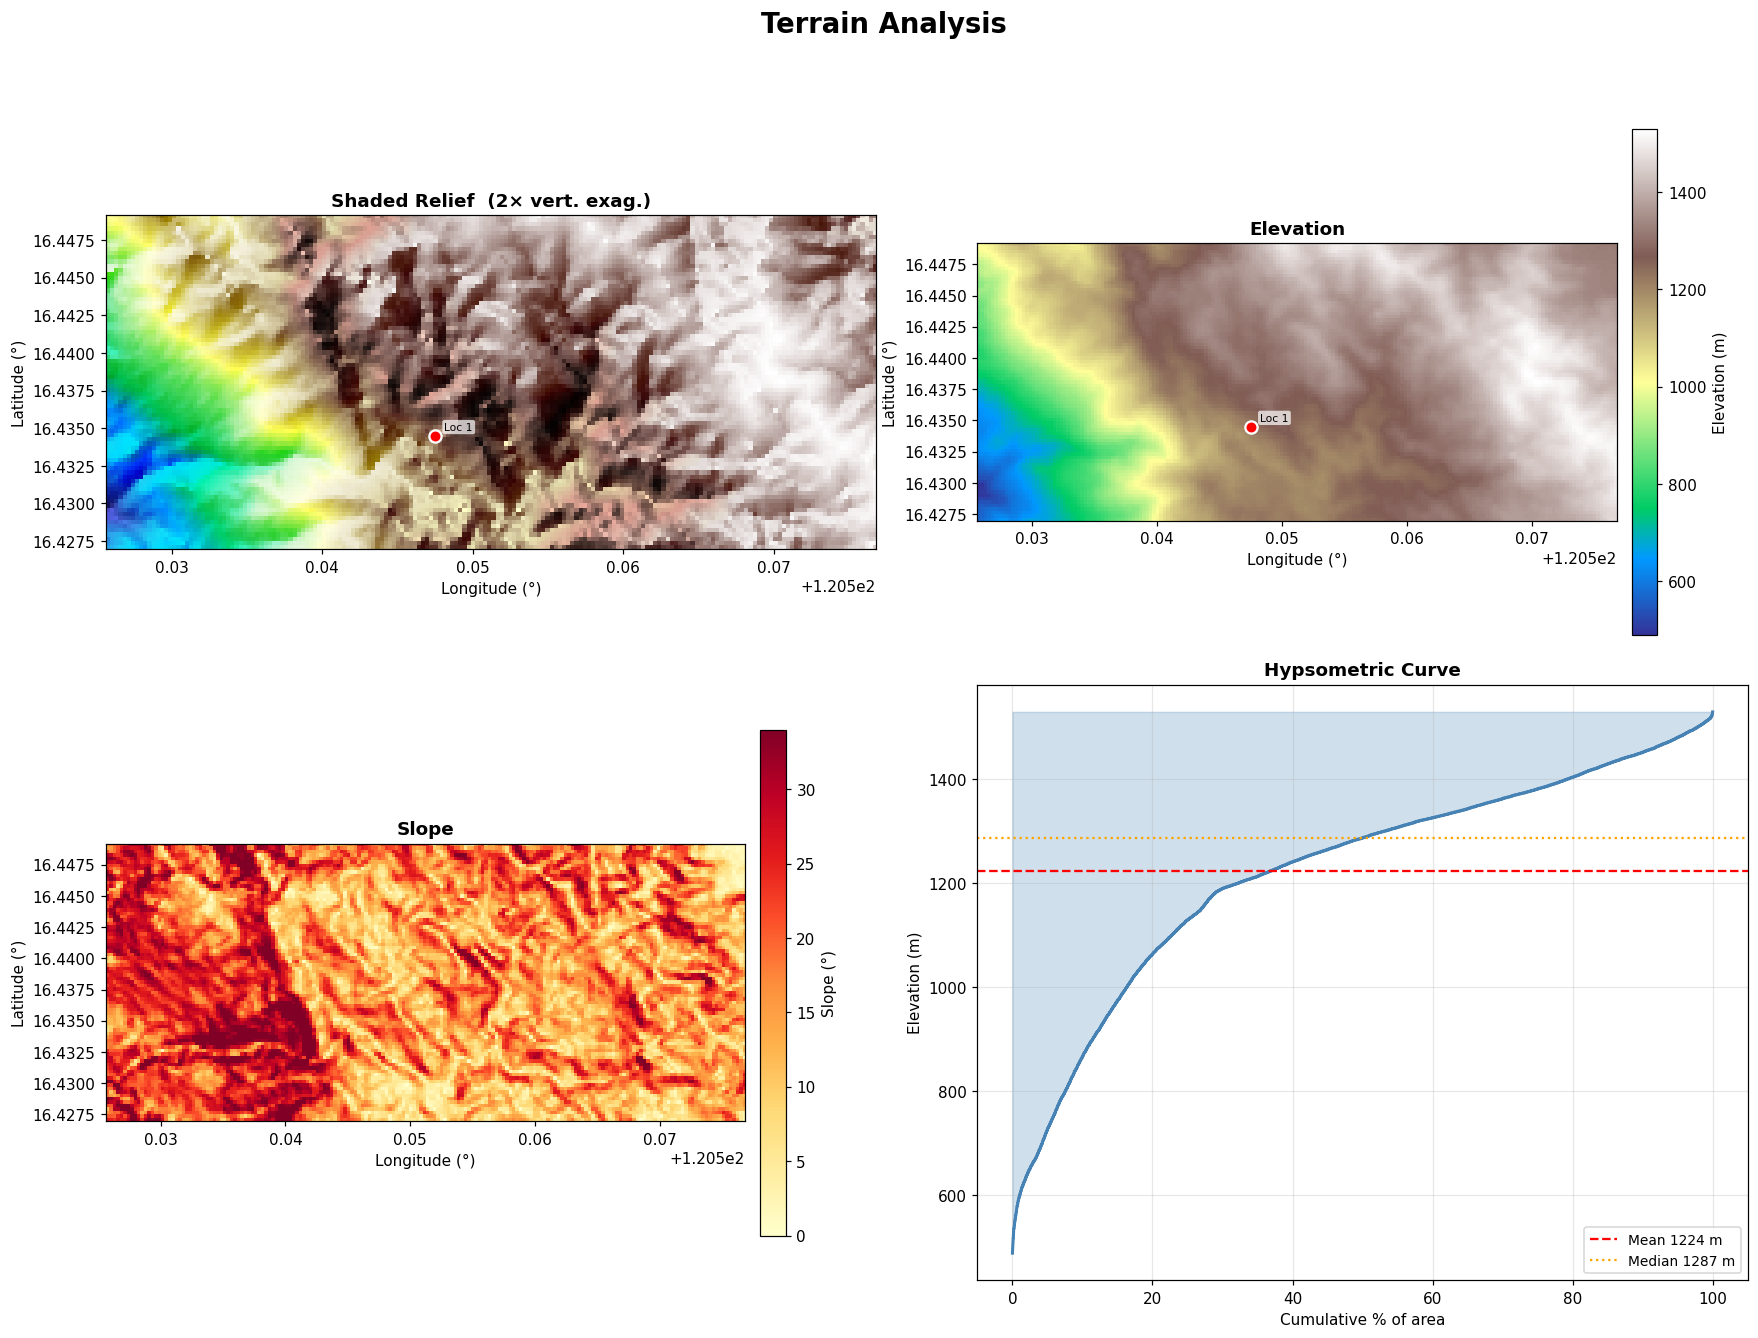

✅ Saved → /content/terrain_analysis.png


In [14]:
ls = LightSource(azdeg=315, altdeg=45)
hs_arr = ls.hillshade(np.where(np.isnan(dem), 0, dem), vert_exag=2.0)
rgb_sr = ls.shade(np.where(np.isnan(dem), 0, dem),
                  cmap=plt.cm.terrain, blend_mode='overlay',
                  vmin=valid.min(), vmax=valid.max(), vert_exag=2.0)

def _plot_pois(ax, poi_list=None):
    """Overlay POI markers on a matplotlib axes."""
    plist = poi_list or poi_store
    for p in plist:
        ax.plot(p['lon'], p['lat'], 'o', color=p['color'],
                ms=8, mec='white', mew=1.5, zorder=6)
        ax.annotate(p['name'], (p['lon'], p['lat']),
                    textcoords='offset points', xytext=(6, 4),
                    fontsize=7, color='black',
                    bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7, ec='none'))

imkw = dict(extent=extent, origin='upper')
fig, axes = plt.subplots(2, 2, figsize=(16, 12), dpi=110)
fig.suptitle('Terrain Analysis', fontsize=18, fontweight='bold', y=1.01)

axes[0,0].imshow(rgb_sr, **imkw)
axes[0,0].set_title('Shaded Relief  (2× vert. exag.)', fontweight='bold')
_plot_pois(axes[0,0])

im2 = axes[0,1].imshow(dem, cmap='terrain', vmin=valid.min(), vmax=valid.max(), **imkw)
plt.colorbar(im2, ax=axes[0,1], label='Elevation (m)', shrink=0.85, pad=0.02)
axes[0,1].set_title('Elevation', fontweight='bold')
_plot_pois(axes[0,1])

slope_cap = np.nanpercentile(slope, 97)
im3 = axes[1,0].imshow(slope, cmap='YlOrRd', vmin=0, vmax=slope_cap, **imkw)
plt.colorbar(im3, ax=axes[1,0], label='Slope (°)', shrink=0.85, pad=0.02)
axes[1,0].set_title('Slope', fontweight='bold')

sv  = np.sort(valid.flatten())
pct = np.linspace(0, 100, len(sv))
axes[1,1].fill_betweenx(sv, pct, alpha=0.25, color='steelblue')
axes[1,1].plot(pct, sv, color='steelblue', lw=2)
axes[1,1].axhline(valid.mean(), ls='--', color='red', lw=1.5,
                   label=f'Mean {valid.mean():.0f} m')
axes[1,1].axhline(np.median(valid), ls=':', color='orange', lw=1.5,
                   label=f'Median {np.median(valid):.0f} m')
axes[1,1].set_xlabel('Cumulative % of area')
axes[1,1].set_ylabel('Elevation (m)')
axes[1,1].set_title('Hypsometric Curve', fontweight='bold')
axes[1,1].legend(fontsize=9); axes[1,1].grid(alpha=0.3)

for ax in axes.flat:
    if ax != axes[1,1]:
        ax.set_xlabel('Longitude (°)'); ax.set_ylabel('Latitude (°)')

plt.tight_layout()
plt.savefig(FIG_TERRAIN, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Saved → {FIG_TERRAIN}")


## 🌊 Step 5 — Hydrologic Processing

```
Raw DEM → Fill Pits → Fill Depressions → Resolve Flats
       → D8 Flow Direction → Flow Accumulation
       → Threshold → Stream Network → Vectorise
```


In [16]:
from pysheds.grid import Grid

print("Loading DEM into pysheds …")
grid    = Grid.from_raster(DEM_PATH)
raw_dem = grid.read_raster(DEM_PATH)

DIRMAP = (64, 128, 1, 2, 4, 8, 16, 32)

print("── Step 1 ─ Fill Pits ──────────────────────────")
pit_filled  = grid.fill_pits(raw_dem);        print("   Done")
print("── Step 2 ─ Fill Depressions ──────────────────")
flooded     = grid.fill_depressions(pit_filled); print("   Done")
print("── Step 3 ─ Resolve Flats ─────────────────────")
conditioned = grid.resolve_flats(flooded);    print("   Done")
print("── Step 4 ─ D8 Flow Direction ─────────────────")
fdir        = grid.flowdir(conditioned, dirmap=DIRMAP); print("   Done")
print("── Step 5 ─ Flow Accumulation ─────────────────")
acc         = grid.accumulation(fdir, dirmap=DIRMAP)
max_acc     = int(np.array(acc).max())
da_thr      = STREAM_THRESHOLD * pxH**2 / 1e6
print(f"   Max accumulation : {max_acc:,} cells")
print(f"   Stream threshold : {STREAM_THRESHOLD:,} cells ≈ {da_thr:.2f} km²")

print("── Step 6 ─ Stream Extraction ─────────────────")
stream_raster  = acc > STREAM_THRESHOLD
n_stream_cells = int(stream_raster.sum())
print(f"   Stream cells     : {n_stream_cells:,}")

print("── Step 7 ─ Vectorise Stream Network ──────────")
branches   = grid.extract_river_network(fdir, stream_raster, dirmap=DIRMAP)
n_branches = len(branches['features'])
print(f"   Stream branches  : {n_branches}")

with open(STREAMS_JSON, 'w') as f: json.dump(branches, f)
print(f"   Saved → {STREAMS_JSON}")
print("\n✅ Hydrologic processing complete!")


Loading DEM into pysheds …
── Step 1 ─ Fill Pits ──────────────────────────
   Done
── Step 2 ─ Fill Depressions ──────────────────
   Done
── Step 3 ─ Resolve Flats ─────────────────────
   Done
── Step 4 ─ D8 Flow Direction ─────────────────
   Done
── Step 5 ─ Flow Accumulation ─────────────────
   Max accumulation : 10,239 cells
   Stream threshold : 50 cells ≈ 0.05 km²
── Step 6 ─ Stream Extraction ─────────────────
   Stream cells     : 1,176
── Step 7 ─ Vectorise Stream Network ──────────
   Stream branches  : 126
   Saved → /content/streams.geojson

✅ Hydrologic processing complete!


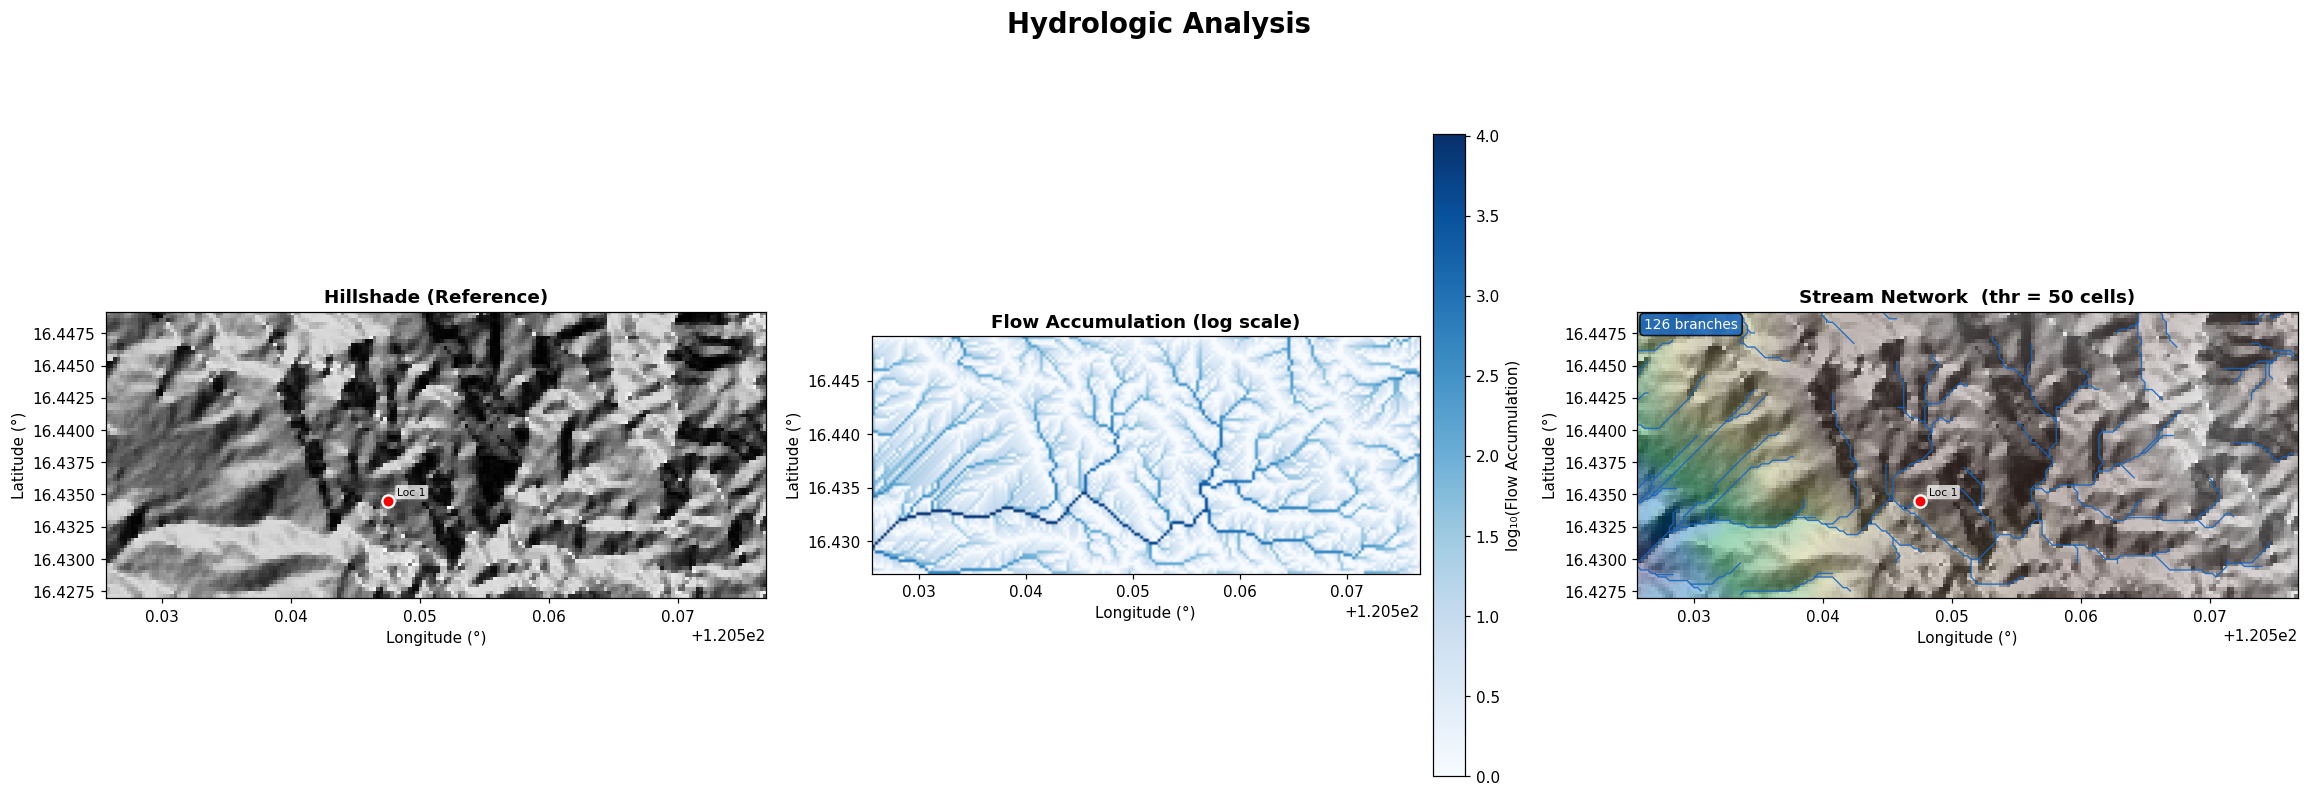

✅ Saved → /content/hydrology_analysis.png


In [17]:
acc_arr = np.array(acc, dtype=float)
log_acc = np.log10(np.where(acc_arr <= 0, np.nan, acc_arr))

fig, axes = plt.subplots(1, 3, figsize=(21, 8), dpi=110)
fig.suptitle('Hydrologic Analysis', fontsize=18, fontweight='bold')
imkw = dict(extent=extent, origin='upper')

axes[0].imshow(hs_arr, cmap='gray', **imkw)
axes[0].set_title('Hillshade (Reference)', fontweight='bold')
_plot_pois(axes[0])

im_acc = axes[1].imshow(log_acc, cmap='Blues', **imkw)
cb = plt.colorbar(im_acc, ax=axes[1], shrink=0.8, pad=0.02)
cb.set_label('log₁₀(Flow Accumulation)')
axes[1].set_title('Flow Accumulation (log scale)', fontweight='bold')

axes[2].imshow(hs_arr, cmap='gray', **imkw)
axes[2].imshow(dem, cmap='terrain', alpha=0.30,
               vmin=valid.min(), vmax=valid.max(), **imkw)
for feat in branches['features']:
    coords = np.array(feat['geometry']['coordinates'])
    if len(coords) > 1:
        axes[2].plot(coords[:,0], coords[:,1],
                     color='#1565c0', lw=0.9, alpha=0.88, solid_capstyle='round')
axes[2].set_xlim(extent[0], extent[1])
axes[2].set_ylim(extent[2], extent[3])
axes[2].set_title(f'Stream Network  (thr = {STREAM_THRESHOLD:,} cells)', fontweight='bold')
axes[2].text(0.01, 0.98, f'{n_branches} branches', transform=axes[2].transAxes,
             va='top', fontsize=9, color='white',
             bbox=dict(boxstyle='round,pad=0.3', fc='#1565c0', alpha=0.85))
_plot_pois(axes[2])

for ax in axes:
    ax.set_xlabel('Longitude (°)'); ax.set_ylabel('Latitude (°)')

plt.tight_layout()
plt.savefig(FIG_HYDRO, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Saved → {FIG_HYDRO}")


## 🎚️ Step 6 — Interactive Stream Threshold Tuning

In [24]:
out_tune = Output()

def _replot_threshold(threshold):
    # sr_new = np.array(acc) > threshold
    sr_new = acc > threshold
    br_new = grid.extract_river_network(fdir, sr_new, dirmap=DIRMAP)
    n_br   = len(br_new['features'])
    with out_tune:
        clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(11, 8), dpi=100)
        ax.imshow(hs_arr, cmap='gray', extent=extent, origin='upper')
        ax.imshow(dem, cmap='terrain', alpha=0.28,
                  vmin=valid.min(), vmax=valid.max(),
                  extent=extent, origin='upper')
        for feat in br_new['features']:
            coords = np.array(feat['geometry']['coordinates'])
            if len(coords) > 1:
                ax.plot(coords[:,0], coords[:,1], color='#1565c0',
                        lw=0.9, alpha=0.9, solid_capstyle='round')
        _plot_pois(ax)
        ax.set_xlim(extent[0], extent[1]); ax.set_ylim(extent[2], extent[3])
        ax.set_title(f'Stream Network  |  threshold = {threshold:,} cells  |  {n_br} branches',
                     fontweight='bold')
        ax.set_xlabel('Longitude (°)'); ax.set_ylabel('Latitude (°)')
        plt.tight_layout(); plt.show()
        print(f"   → {n_br} branches | drainage area/channel ≈ {threshold*pxH**2/1e6:.3f} km²")

max_slider = max(5000, STREAM_THRESHOLD * 8)
slider = IntSlider(value=STREAM_THRESHOLD, min=50, max=max_slider, step=50,
                   description='Threshold:', continuous_update=False,
                   style={'description_width': '80px'},
                   layout=Layout(width='520px'))

display(VBox([
    HTML("<h4>🎚️ Flow-Accumulation Threshold</h4>"
         "<p style='color:#555'>↓ Lower = denser network | ↑ Higher = main channels only</p>"),
    slider, out_tune
]))
widgets.interactive(_replot_threshold, threshold=slider)
_replot_threshold(STREAM_THRESHOLD)


## 🗺️ Step 7 — Interactive Watershed / Catchment Delineation

**Two ways to set the pour point:**

| Method | How |
|--------|-----|
| **Click on map** | Enable *Click Mode* → click anywhere (on stream or off); point snaps to nearest stream cell |
| **Type coordinates** | Enter lat/lon in the text boxes → click *Delineate* |

The delineated catchment boundary and pour point are:
- Shown on both an interactive map and a static figure  
- Exported as GeoJSON and Shapefile  
- Statistics printed (area, perimeter, mean/max elevation within catchment)


In [29]:
# ═══════════════════════════════════════════════════════════════════════════
#  INTERACTIVE WATERSHED DELINEATION
# ═══════════════════════════════════════════════════════════════════════════

# ── Pre-build a KD-tree of stream cell centres (for fast snapping) ────────────
from scipy.spatial import cKDTree

acc_arr2d  = np.array(acc)
stream_ij  = np.argwhere(stream_raster)          # (row, col) of stream cells

def _rc_to_lonlat(row, col):
    lon = transform.c + (col + 0.5) * transform.a
    lat = transform.f + (row + 0.5) * transform.e
    return lon, lat

stream_lonlat = np.array([_rc_to_lonlat(r, c) for r, c in stream_ij])  # (N,2): lon,lat
stream_tree   = cKDTree(stream_lonlat)

def snap_to_stream(lon, lat):
    """Return (lon_snap, lat_snap, row, col) of nearest stream cell."""
    _, idx = stream_tree.query([lon, lat])
    r, c   = stream_ij[idx]
    lo, la = stream_lonlat[idx]
    return float(lo), float(la), int(r), int(c)

# ── Delineation function ──────────────────────────────────────────────────────
_watershed_result = {}

def delineate_watershed(lon_in, lat_in):
    """
    Snap (lon_in, lat_in) to the nearest stream cell, delineate its upstream
    catchment, compute statistics, save outputs and return a result dict.
    """
    lon_s, lat_s, r_s, c_s = snap_to_stream(lon_in, lat_in)
    acc_at_snap   = int(np.array(acc)[r_s, c_s])
    drain_area_km2 = acc_at_snap * pxH * pxW / 1e6
    dist_m = np.sqrt(((lon_in - lon_s)*m_per_degx)**2
                   + ((lat_in - lat_s)*m_per_degy)**2)
    print(f"   Input point       : ({lat_in:.5f}°, {lon_in:.5f}°)")
    print(f"   Snapped to        : ({lat_s:.5f}°, {lon_s:.5f}°)  Δ={dist_m:.1f} m")
    print(f"   Accum. at snap    : {acc_at_snap:,} cells")
    print(f"   Drainage area     : {drain_area_km2:.4f} km²  ({drain_area_km2*100:.2f} ha)")

    # Reset grid viewfinder to full DEM extent
    grid.viewfinder = fdir.viewfinder

    # Delineate
    catch = grid.catchment(lon_s, lat_s, fdir, dirmap=DIRMAP, xytype='coordinate')

    # ← THE KEY FIX: re-view the result at the full fdir extent, filling outside with 0
    catch_full = grid.view(catch, target_view=fdir.viewfinder, nodata=0)
    catch_v    = np.array(catch_full).astype(np.uint8)

    # ── Statistics ─────────────────────────────────────────────────────────────
    # This should already be correct after the fix above, but double-check:
    mask           = catch_v.astype(bool)        # shape == dem.shape  ✓
    elev_in_catch  = dem[mask]                   # pulls full catchment elevations ✓
    elev_in_catch = elev_in_catch[~np.isnan(elev_in_catch)]
    area_cells    = int(mask.sum())
    area_km2      = area_cells * pxH * pxW / 1e6
    # Perimeter: count boundary cells
    from scipy.ndimage import binary_erosion
    interior  = binary_erosion(mask)
    boundary  = mask & ~interior
    perim_km  = int(boundary.sum()) * np.mean([pxH, pxW]) / 1000

    print(f"\n   ── Catchment Statistics ──────────────────")
    print(f"   Cells        : {area_cells:,}")
    print(f"   Area         : {area_km2:.3f} km²  ({area_km2*100:.1f} ha)")
    print(f"   Perimeter    : {perim_km:.2f} km")
    if len(elev_in_catch):
        print(f"   Elev min     : {elev_in_catch.min():.1f} m")
        print(f"   Elev max     : {elev_in_catch.max():.1f} m")
        print(f"   Elev mean    : {elev_in_catch.mean():.1f} m")
        print(f"   Elev relief  : {elev_in_catch.max()-elev_in_catch.min():.1f} m")

    # ── Vectorise catchment boundary ──────────────────────────────────────────
    from rasterio.features import shapes as rio_shapes
    catch_int = catch_v.astype(np.uint8)
    # Use transform to get geographic coordinates
    geoms = [shape(s) for s, v in rio_shapes(catch_int, transform=transform) if v == 1]
    if not geoms:
        print("⚠️  Could not vectorise catchment polygon.")
        return None
    from shapely.ops import unary_union
    catch_poly = unary_union(geoms)

    gdf_catch = gpd.GeoDataFrame([{
        'pour_lat': lat_in, 'pour_lon': lon_in,
        'snap_lat': lat_s,  'snap_lon': lon_s,
        'area_km2': round(area_km2, 4),
        'perim_km': round(perim_km, 4),
        'elev_min': round(float(elev_in_catch.min()), 1) if len(elev_in_catch) else None,
        'elev_max': round(float(elev_in_catch.max()), 1) if len(elev_in_catch) else None,
        'elev_mean':round(float(elev_in_catch.mean()),1) if len(elev_in_catch) else None,
    }], geometry=[catch_poly], crs='EPSG:4326')

    gdf_catch.to_file(WATERSHED_JSON, driver='GeoJSON')
    gdf_catch.to_file(WATERSHED_SHP)
    print(f"\n   Saved → {WATERSHED_JSON}")
    print(f"   Saved → {WATERSHED_SHP}")

    result = dict(
        lon_in=lon_in, lat_in=lat_in,
        lon_s=lon_s,   lat_s=lat_s,
        mask=mask, area_km2=area_km2, perim_km=perim_km,
        elev_in=elev_in_catch, gdf=gdf_catch, poly=catch_poly
    )
    _watershed_result.update(result)
    return result

print("✅ Watershed delineation engine ready")
print(f"   Stream network : {len(stream_ij):,} cells indexed in KD-tree")


✅ Watershed delineation engine ready
   Stream network : 1,176 cells indexed in KD-tree


In [30]:
# ═══════════════════════════════════════════════════════════════════════════
#  WATERSHED DELINEATION WIDGET
# ═══════════════════════════════════════════════════════════════════════════

out_ws_map = Output()
out_ws_fig = Output()
out_ws_log = Output()

# ── Map for clicking ──────────────────────────────────────────────────────────
m_ws = Map(
    center=[(bbox.top+bbox.bottom)/2, (bbox.left+bbox.right)/2],
    zoom=DEFAULT_ZOOM,
    scroll_wheel_zoom=True,
    layout=Layout(height='480px', width='100%')
)

# Satellite + stream overlay as default
m_ws.add_layer(TileLayer(
    url='https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',
    attribution='Esri', name='Satellite'))
m_ws.add_layer(TileLayer(
    url='https://{s}.tile.openstreetmap.org/{z}/{x}/{y}.png',
    attribution='OSM', name='OpenStreetMap'))
m_ws.add_control(LayersControl(position='topright'))
m_ws.add_control(ScaleControl(position='bottomleft'))

# Draw stream network on the map
stream_geojson_layer = LeafletGeoJSON(
    data=branches,
    style={'color': '#1565c0', 'weight': 2, 'opacity': 0.85}
)
m_ws.add_layer(stream_geojson_layer)

# ── State ─────────────────────────────────────────────────────────────────────
_ws_layers = []      # catchment polygon + markers
_click_mode = [False]
_pending_marker = [None]

def _clear_ws_layers():
    for lyr in _ws_layers:
        try: m_ws.remove_layer(lyr)
        except: pass
    _ws_layers.clear()

# ── Coordinate inputs ─────────────────────────────────────────────────────────
f_lat = FloatText(value=round((bbox.top+bbox.bottom)/2, 5),
                  description='Latitude:',  step=0.0001,
                  layout=Layout(width='220px'))
f_lon = FloatText(value=round((bbox.left+bbox.right)/2, 5),
                  description='Longitude:', step=0.0001,
                  layout=Layout(width='220px'))

# ── Main delineation logic ────────────────────────────────────────────────────
def _run_delineation(lon_in, lat_in):
    out_ws_log.clear_output()
    with out_ws_log:
        print(f"\n🔍 Delineating watershed for ({lat_in:.5f}°, {lon_in:.5f}°) …\n")
    try:
        res = delineate_watershed(lon_in, lat_in)
    except Exception as ex:
        with out_ws_log:
            print(f"❌ Error: {ex}")
        return
    if res is None: return

    # ── Update map ─────────────────────────────────────────────────────────────
    _clear_ws_layers()

    # Catchment polygon as GeoJSON layer
    catch_lyr = LeafletGeoJSON(
        data=json.loads(res['gdf'].to_json()),
        style={'color': '#e65100', 'weight': 2.5,
               'fillColor': '#ff8f00', 'fillOpacity': 0.25}
    )
    m_ws.add_layer(catch_lyr)
    _ws_layers.append(catch_lyr)

    # Input point marker
    mk_in = CircleMarker(location=(lat_in, lon_in),
                         radius=7, color='white', weight=2,
                         fill_color='#e65100', fill_opacity=1.0)
    mk_in.popup = Popup(child=HTML(
        f"<b>Input point</b><br>{lat_in:.5f}°, {lon_in:.5f}°"
    ), close_button=False)
    m_ws.add_layer(mk_in); _ws_layers.append(mk_in)

    # Snapped pour-point marker
    mk_snap = CircleMarker(location=(res['lat_s'], res['lon_s']),
                           radius=9, color='white', weight=2,
                           fill_color='#1a237e', fill_opacity=1.0)
    mk_snap.popup = Popup(child=HTML(
        f"<b>Pour point (snapped)</b><br>"
        f"{res['lat_s']:.5f}°, {res['lon_s']:.5f}°<br>"
        f"Area: {res['area_km2']:.3f} km²"
    ), close_button=False)
    m_ws.add_layer(mk_snap); _ws_layers.append(mk_snap)

    # Zoom map to catchment
    b = res['poly'].bounds   # (minx, miny, maxx, maxy)
    m_ws.fit_bounds([[b[1], b[0]], [b[3], b[2]]])

    # ── Static figure ─────────────────────────────────────────────────────────
    out_ws_fig.clear_output()
    with out_ws_fig:
        fig, axes = plt.subplots(1, 2, figsize=(16, 7), dpi=110)
        fig.suptitle(
            f'Watershed Delineation  |  Area = {res["area_km2"]:.3f} km²',
            fontsize=16, fontweight='bold'
        )
        imkw2 = dict(extent=extent, origin='upper')

        # Left: hillshade + catchment mask + streams
        axes[0].imshow(hs_arr, cmap='gray', **imkw2)
        axes[0].imshow(dem, cmap='terrain', alpha=0.3,
                       vmin=valid.min(), vmax=valid.max(), **imkw2)
        catch_overlay = np.where(res['mask'], 1.0, np.nan)
        axes[0].imshow(catch_overlay, cmap='autumn', alpha=0.35, **imkw2)
        for feat in branches['features']:
            coords = np.array(feat['geometry']['coordinates'])
            if len(coords) > 1:
                axes[0].plot(coords[:,0], coords[:,1],
                             color='#1565c0', lw=0.8, alpha=0.85)
        # Catchment boundary
        from shapely.plotting import plot_polygon
        try:
            plot_polygon(res['poly'], ax=axes[0], add_points=False,
                        facecolor='none', edgecolor='#e65100', linewidth=2.2)
        except Exception:
            x_b, y_b = res['poly'].exterior.xy
            axes[0].plot(x_b, y_b, '-', color='#e65100', lw=2.2)
        axes[0].plot(lon_in, lat_in, 'v', color='#e65100', ms=12, zorder=7,
                     label='Input point', mec='white', mew=1.5)
        axes[0].plot(res['lon_s'], res['lat_s'], 'v', color='#1a237e', ms=12,
                     zorder=8, label='Pour point (snapped)', mec='white', mew=1.5)
        _plot_pois(axes[0])
        axes[0].set_xlim(extent[0], extent[1]); axes[0].set_ylim(extent[2], extent[3])
        axes[0].set_title('Catchment Boundary', fontweight='bold')
        axes[0].set_xlabel('Longitude (°)'); axes[0].set_ylabel('Latitude (°)')
        axes[0].legend(fontsize=9)

        # Right: elevation histogram for catchment
        ev = res['elev_in']
        if len(ev):
            n_bins = min(60, max(20, len(ev)//500))
            axes[1].hist(ev, bins=n_bins, color='#5c85d6', edgecolor='white',
                         linewidth=0.5, density=True)
            axes[1].axvline(ev.mean(), color='red', lw=2, ls='--',
                            label=f'Mean {ev.mean():.0f} m')
            axes[1].axvline(np.median(ev), color='orange', lw=2, ls=':',
                            label=f'Median {np.median(ev):.0f} m')
            axes[1].set_xlabel('Elevation (m)'); axes[1].set_ylabel('Density')
            axes[1].set_title('Catchment Elevation Distribution', fontweight='bold')
            axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)
            # Annotation box
            txt = (f"Area      : {res['area_km2']:.3f} km²\n"
                   f"Perimeter : {res['perim_km']:.2f} km\n"
                   f"Elev min  : {ev.min():.1f} m\n"
                   f"Elev max  : {ev.max():.1f} m\n"
                   f"Elev mean : {ev.mean():.1f} m\n"
                   f"Relief    : {ev.max()-ev.min():.1f} m")
            axes[1].text(0.97, 0.97, txt, transform=axes[1].transAxes,
                         va='top', ha='right', fontsize=9, family='monospace',
                         bbox=dict(boxstyle='round', fc='#fffde7', ec='#fbc02d', alpha=0.9))

        plt.tight_layout()
        plt.savefig(FIG_WATERSHED, dpi=150, bbox_inches='tight')
        plt.show()
        print(f"✅ Saved → {FIG_WATERSHED}")

    with out_ws_log:
        print("\n✅ Delineation complete!")
        print(f"   GeoJSON  → {WATERSHED_JSON}")
        print(f"   Shapefile→ {WATERSHED_SHP}")

# ── Click-on-map handler ──────────────────────────────────────────────────────

def on_map_click(**kwargs):
    if not _click_mode[0]: return
    if kwargs.get('type') != 'click': return   # ← ignore mousemove, mouseout, etc.
    coords = kwargs.get('coordinates')
    if not coords: return
    lat_c, lon_c = float(coords[0]), float(coords[1])
    f_lat.value = round(lat_c, 6)
    f_lon.value = round(lon_c, 6)
    # Remove previous pending marker
    if _pending_marker[0]:
        try: m_ws.remove_layer(_pending_marker[0])
        except: pass
    mk = CircleMarker(location=(lat_c, lon_c), radius=6,
                      color='yellow', weight=2,
                      fill_color='#e65100', fill_opacity=0.9)
    m_ws.add_layer(mk)
    _pending_marker[0] = mk
    with out_ws_log:
        clear_output(wait=True)
        print(f"📌 Clicked: ({lat_c:.5f}°, {lon_c:.5f}°)  → click 🌊 Delineate to run")

m_ws.on_interaction(on_map_click)
# ── Buttons ───────────────────────────────────────────────────────────────────
btn_click_mode  = ToggleButton(value=False, description='🖱️ Click Mode: OFF',
                                button_style='', icon='map-marker',
                                layout=Layout(width='180px', height='38px'))
btn_delineate   = Button(description='🌊 Delineate Watershed',
                          button_style='success',
                          layout=Layout(width='200px', height='38px'))
btn_clear_ws    = Button(description='🗑️ Clear',
                          button_style='danger',
                          layout=Layout(width='100px', height='38px'))

def on_toggle_click(change):
    if change['name'] == 'value':
        if change['new']:
            btn_click_mode.description = '🖱️ Click Mode: ON'
            btn_click_mode.button_style = 'warning'
            _click_mode[0] = True
        else:
            btn_click_mode.description = '🖱️ Click Mode: OFF'
            btn_click_mode.button_style = ''
            _click_mode[0] = False

btn_click_mode.observe(on_toggle_click)

def on_delineate(b):
    _run_delineation(f_lon.value, f_lat.value)

def on_clear_ws(b):
    _clear_ws_layers()
    if _pending_marker[0]:
        try: m_ws.remove_layer(_pending_marker[0])
        except: pass
        _pending_marker[0] = None
    out_ws_log.clear_output()
    out_ws_fig.clear_output()

btn_delineate.on_click(on_delineate)
btn_clear_ws.on_click(on_clear_ws)

# ── Layout ────────────────────────────────────────────────────────────────────
display(VBox([
    HTML(
        "<h3 style='margin:4px 0'>🗺️ Watershed Delineation</h3>"
        "<p style='color:#555;margin:2px 0'>"
        "Enable <b>Click Mode</b> and click on the map, or type coordinates directly. "
        "The point will snap to the nearest stream cell automatically."
        "</p>"
    ),
    HTML("<b style='color:#1565c0'>Blue lines = stream network. "
         "Click a stream section or any point inside the basin.</b>"),
    m_ws,
    HBox([btn_click_mode,
          HTML("&nbsp;&nbsp;<b>─ or type coordinates ─</b>&nbsp;&nbsp;"),
          f_lat, f_lon,
          HTML("&nbsp;"),
          btn_delineate, btn_clear_ws],
         layout=Layout(gap='6px', align_items='center', flex_wrap='wrap',
                       margin='8px 0')),
    out_ws_log,
    out_ws_fig
]))


   Input point       : (16.43096°, 120.55300°)
   Snapped to        : (16.43093°, 120.55327°)  Δ=28.1 m
   Accum. at snap    : 4,898 cells
   Drainage area     : 4.3972 km²  (439.72 ha)

   ── Catchment Statistics ──────────────────
   Cells        : 4,847
   Area         : 4.351 km²  (435.1 ha)
   Perimeter    : 8.99 km
   Elev min     : 1193.0 m
   Elev max     : 1529.0 m
   Elev mean    : 1358.4 m
   Elev relief  : 336.0 m

   Saved → /content/watershed.geojson
   Saved → /content/watershed.shp


## 📦 Step 8 — Export All Results

In [32]:
# ══════════════════════════════════════════════════════════════════════════════
#  STEP 8 — EXPORT ALL RESULTS
# ══════════════════════════════════════════════════════════════════════════════

GPKG_PATH = '/content/dem_analysis.gpkg'

# ── 1. Streams ─────────────────────────────────────────────────────────────────
gdf_streams = gpd.read_file(STREAMS_JSON)
if gdf_streams.crs is None:
    gdf_streams = gdf_streams.set_crs(epsg=4326)
gdf_streams = gdf_streams[
    ~gdf_streams.geometry.isna() &
    ~gdf_streams.geometry.is_empty &
    gdf_streams.geometry.geom_type.isin(['LineString','MultiLineString'])
].copy()
gdf_streams.to_file(STREAMS_JSON, driver='GeoJSON')       # overwrite clean version
gdf_streams.to_file(GPKG_PATH, layer='streams', driver='GPKG')
print(f"✅ Streams      → {len(gdf_streams)} features")

# ── 2. Watershed ───────────────────────────────────────────────────────────────
if os.path.exists(WATERSHED_JSON):
    gdf_ws = gpd.read_file(WATERSHED_JSON)
    if gdf_ws.crs is None:
        gdf_ws = gdf_ws.set_crs(epsg=4326)
    gdf_ws.to_file(WATERSHED_JSON, driver='GeoJSON')
    gdf_ws.to_file(GPKG_PATH, layer='watershed', driver='GPKG')
    print(f"✅ Watershed    → {len(gdf_ws)} feature(s), "
          f"{gdf_ws.iloc[0].get('area_km2', '?')} km²")
else:
    print("⬜ Watershed    → not generated (run Step 7 first)")

# ── 3. POIs ────────────────────────────────────────────────────────────────────
if poi_store:
    gdf_poi = gpd.GeoDataFrame(
        poi_store,
        geometry=[Point(p['lon'], p['lat']) for p in poi_store],
        crs='EPSG:4326'
    )
    gdf_poi.to_file('/content/points_of_interest.geojson', driver='GeoJSON')
    gdf_poi.to_file(GPKG_PATH, layer='points_of_interest', driver='GPKG')
    print(f"✅ POIs         → {len(poi_store)} point(s)")
else:
    print("⬜ POIs         → none loaded (optional)")

# ── 4. Summary table ───────────────────────────────────────────────────────────
print()
outputs = [
    (DEM_PATH,                              'DEM — SRTM 30 m (GeoTIFF)'),
    (STREAMS_JSON,                          'Stream network (GeoJSON)'),
    (WATERSHED_JSON,                        'Watershed boundary (GeoJSON)'),
    ('/content/points_of_interest.geojson', 'Points of interest (GeoJSON)'),
    (GPKG_PATH,                             'All vector layers (GeoPackage) ← QField-ready'),
    (FIG_TERRAIN,                           'Terrain analysis figure (PNG)'),
    (FIG_HYDRO,                             'Hydrologic analysis figure (PNG)'),
    (FIG_WATERSHED,                         'Watershed figure (PNG)'),
]

print("📋 Output files:")
for path, label in outputs:
    exists = os.path.exists(path)
    mark   = '✅' if exists else '⬜'
    kb     = f"{os.path.getsize(path)/1024:.1f} KB" if exists else "not generated"
    print(f"  {mark}  {label:<48} {kb}")
    print(f"       → {path}")

# ── 5. Download instructions ───────────────────────────────────────────────────
print("""
─── Download the GeoPackage (all layers in one file) ───────────────────
from google.colab import files
files.download('/content/dem_analysis.gpkg')

─── Download individual GeoJSON files ──────────────────────────────────
files.download('/content/streams.geojson')
files.download('/content/watershed.geojson')
files.download('/content/points_of_interest.geojson')
files.download('/content/dem.tif')

─── Or zip everything ───────────────────────────────────────────────────
import shutil
shutil.make_archive('/content/dem_analysis', 'zip', '/content')
files.download('/content/dem_analysis.zip')

─── Open in QField (Android / iOS) ─────────────────────────────────────
  QField → + → Open local file → dem_analysis.gpkg
  All layers (streams, watershed, POIs) load at once, no QGIS needed.
""")

✅ Streams      → 126 features
✅ Watershed    → 1 feature(s), 4.3514 km²
✅ POIs         → 1 point(s)

📋 Output files:
  ✅  DEM — SRTM 30 m (GeoTIFF)                        59.3 KB
       → /content/dem.tif
  ✅  Stream network (GeoJSON)                         44.1 KB
       → /content/streams.geojson
  ✅  Watershed boundary (GeoJSON)                     10.3 KB
       → /content/watershed.geojson
  ✅  Points of interest (GeoJSON)                     0.4 KB
       → /content/points_of_interest.geojson
  ✅  All vector layers (GeoPackage) ← QField-ready    172.0 KB
       → /content/dem_analysis.gpkg
  ✅  Terrain analysis figure (PNG)                    357.0 KB
       → /content/terrain_analysis.png
  ✅  Hydrologic analysis figure (PNG)                 307.1 KB
       → /content/hydrology_analysis.png
  ✅  Watershed figure (PNG)                           252.5 KB
       → /content/watershed.png

─── Download the GeoPackage (all layers in one file) ───────────────────
from google.colab imp

## 💡 Tips & Reference

### POI / Vector file formats accepted
| Format | Notes |
|--------|-------|
| GeoJSON (`.geojson`, `.json`) | Points, lines, polygons — centroids used for non-points |
| Zipped Shapefile (`.zip`) | Must contain `.shp`, `.shx`, `.dbf` inside the ZIP |
| Paste GeoJSON | Raw FeatureCollection text in the textarea |

### Watershed delineation notes
- **Snap distance**: the tool finds the nearest stream cell in the indexed KD-tree, so off-stream clicks are corrected automatically.
- **Resolution limitation**: at 30 m, very small catchments (<1 km²) may have low-precision boundaries.
- **Multiple watersheds**: re-run Step 7 with different pour points — each overwrites the previous export. Copy files between runs.

### Equivalent QGIS / GRASS workflow
```bash
# GRASS-GIS
r.fill.dir    input=dem output=dem_filled
r.watershed   elevation=dem_filled threshold=500 stream=streams basin=basins
r.to.vect     input=basins output=basins type=area
r.to.vect     input=streams output=streams type=line
```

### DEM source comparison
| Source | Res. | Coverage | Free | Key |
|--------|------|---------|------|-----|
| SRTM (AWS) | 30 m | 60°N–56°S | ✅ | None |
| COP30 (OT) | 30 m | Global | ✅ | Free |
| NASADEM (OT)| 30 m | 60°N–56°S | ✅ | Free |
| AW3D30 (OT) | 30 m | Global | ✅ | Free |
